In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

📌 PROBLEM STATEMENT

You are given:
1) Customer demographic
2) Customer behavioral and transactional data
3) Some records have missing values for the target: future credit card consumption

🎯 OBJECTIVE:
Build a supervised ML model to predict average credit card consumption for July-Sept using April-June data.

Evaluate with RMSPE (Root Mean Squared Percentage Error)

In [2]:
# Load Datasets
df_demog = pd.read_excel("CustomerDemographics.xlsx")
df_behavior = pd.read_excel("CustomerBehaviorData.xlsx")
df_target = pd.read_excel("CreditConsumptionData.xlsx")

In [3]:
df_demog.head()

,ID,account_type,gender,age,Income,Emp_Tenure_Years,Tenure_with_Bank,region_code,NetBanking_Flag,Avg_days_between_transaction
0,17051,current,M,30,MEDIUM,26.4,9,9,355,0
1,11491,current,M,37,LOW,14.4,7,7,485,0
2,7433,current,M,33,MEDIUM,3.2,1,1,764,0
3,14606,current,M,63,LOW,10.2,6,6,863,0
4,8381,saving,M,33,MEDIUM,26.4,6,6,523,0


In [4]:
df_behavior.head()

,ID,cc_cons_apr,dc_cons_apr,cc_cons_may,dc_cons_may,cc_cons_jun,dc_cons_jun,cc_count_apr,cc_count_may,cc_count_jun,...,credit_count_may,debit_count_may,max_credit_amount_may,debit_amount_jun,credit_amount_jun,credit_count_jun,debit_count_jun,max_credit_amount_jun,loan_enq,emi_active
0,17051,2017.46,29066.66,15919.84,2197.00,3752.000,29798.00,1.0,4,35,...,47,20,41860.0,32734.75,80959.00,36,9,171200.0,Y,3448.84
1,11491,7687.00,1308.00,41888.92,2216.92,7060.530,3143.36,2.0,27,50,...,0,8,113367.0,60974.75,495080.00,5,3,15694.0,Y,3812.69
2,7433,9094.46,14825.95,3087.64,769.59,25602.595,1445.00,44.0,8,47,...,2,14,168000.0,425802.96,115707.38,7,58,28058.0,Y,9432.90
3,14606,3126.00,4616.33,8676.80,5923.00,6717.000,18747.00,4.0,30,1,...,45,44,57750.0,25537.91,63606.00,12,0,24459.0,Y,144.61
4,8381,24988.72,10091.23,10132.00,3477.00,4667.000,511.00,2.0,8,5,...,1,2,18405.0,64687.32,62353.35,49,35,31574.0,Y,1887.89


In [5]:
df_behavior.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 39 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     20000 non-null  int64  
 1   cc_cons_apr            20000 non-null  float64
 2   dc_cons_apr            20000 non-null  float64
 3   cc_cons_may            19999 non-null  float64
 4   dc_cons_may            19999 non-null  float64
 5   cc_cons_jun            20000 non-null  float64
 6   dc_cons_jun            19999 non-null  float64
 7   cc_count_apr           19999 non-null  float64
 8   cc_count_may           20000 non-null  int64  
 9   cc_count_jun           20000 non-null  int64  
 10  dc_count_apr           20000 non-null  int64  
 11  dc_count_may           20000 non-null  int64  
 12  dc_count_jun           20000 non-null  int64  
 13  card_lim               20000 non-null  int64  
 14  personal_loan_active   20000 non-null  int64  
 15  ve

In [6]:
df_target.head()

,ID,cc_cons
0,17051,16239.0
1,11491,39002.0
2,7433,21182.0
3,14606,8123.0
4,8381,28282.0


In [7]:
df_target.info() 
# missing data in cc_cons column makes it our target value to predict 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ID       20000 non-null  int64  
 1   cc_cons  15000 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 312.6 KB


In [8]:
# Merge
df = df_demog.merge(df_behavior, on='ID').merge(df_target, on='ID')

In [9]:
df.head()

,ID,account_type,gender,age,Income,Emp_Tenure_Years,Tenure_with_Bank,region_code,NetBanking_Flag,Avg_days_between_transaction,...,debit_count_may,max_credit_amount_may,debit_amount_jun,credit_amount_jun,credit_count_jun,debit_count_jun,max_credit_amount_jun,loan_enq,emi_active,cc_cons
0,17051,current,M,30,MEDIUM,26.4,9,9,355,0,...,20,41860.0,32734.75,80959.00,36,9,171200.0,Y,3448.84,16239.0
1,11491,current,M,37,LOW,14.4,7,7,485,0,...,8,113367.0,60974.75,495080.00,5,3,15694.0,Y,3812.69,39002.0
2,7433,current,M,33,MEDIUM,3.2,1,1,764,0,...,14,168000.0,425802.96,115707.38,7,58,28058.0,Y,9432.90,21182.0
3,14606,current,M,63,LOW,10.2,6,6,863,0,...,44,57750.0,25537.91,63606.00,12,0,24459.0,Y,144.61,8123.0
4,8381,saving,M,33,MEDIUM,26.4,6,6,523,0,...,2,18405.0,64687.32,62353.35,49,35,31574.0,Y,1887.89,28282.0


In [10]:
# Separate rows with missing target
df_predict = df[df['cc_cons'].isnull()] 
# df['cc_cons'].isnull() means target is missing 
# These rows are the real life test cases, to be predicted later

df_train = df[~df['cc_cons'].isnull()]
# ~df['cc_cons'].isnull() means target is not missing 
# These rows are the real training data, we already know the outcome, so we train out model on them 

In [11]:
# Check missing values
df_train.isnull().sum()

ID                              0
account_type                    0
gender                          0
age                             0
Income                          0
Emp_Tenure_Years                0
Tenure_with_Bank                0
region_code                     0
NetBanking_Flag                 0
Avg_days_between_transaction    0
cc_cons_apr                     0
dc_cons_apr                     0
cc_cons_may                     0
dc_cons_may                     1
cc_cons_jun                     0
dc_cons_jun                     0
cc_count_apr                    1
cc_count_may                    0
cc_count_jun                    0
dc_count_apr                    0
dc_count_may                    0
dc_count_jun                    0
card_lim                        0
personal_loan_active            0
vehicle_loan_active             0
personal_loan_closed            1
vehicle_loan_closed             0
investment_1                    0
investment_2                    0
investment_3  

In [12]:
df_train.shape

(15000, 49)

In [13]:
df_predict.shape

(5000, 49)

In [14]:
df_train.isnull().sum()

ID                              0
account_type                    0
gender                          0
age                             0
Income                          0
Emp_Tenure_Years                0
Tenure_with_Bank                0
region_code                     0
NetBanking_Flag                 0
Avg_days_between_transaction    0
cc_cons_apr                     0
dc_cons_apr                     0
cc_cons_may                     0
dc_cons_may                     1
cc_cons_jun                     0
dc_cons_jun                     0
cc_count_apr                    1
cc_count_may                    0
cc_count_jun                    0
dc_count_apr                    0
dc_count_may                    0
dc_count_jun                    0
card_lim                        0
personal_loan_active            0
vehicle_loan_active             0
personal_loan_closed            1
vehicle_loan_closed             0
investment_1                    0
investment_2                    0
investment_3  

In [15]:
df.duplicated().sum()

0

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 49 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            20000 non-null  int64  
 1   account_type                  20000 non-null  object 
 2   gender                        20000 non-null  object 
 3   age                           20000 non-null  int64  
 4   Income                        20000 non-null  object 
 5   Emp_Tenure_Years              20000 non-null  float64
 6   Tenure_with_Bank              20000 non-null  int64  
 7   region_code                   20000 non-null  int64  
 8   NetBanking_Flag               20000 non-null  int64  
 9   Avg_days_between_transaction  20000 non-null  int64  
 10  cc_cons_apr                   20000 non-null  float64
 11  dc_cons_apr                   20000 non-null  float64
 12  cc_cons_may                   19999 non-null  float64
 13  d

In [17]:
df.shape

(20000, 49)

In [18]:
# Why fill with O was also suitable in this case 
# Business Logic: for transactional/loan/investment data if it's missing it likely means not done or zero
# Minimal Imputation Risk 
# We retain 100% of customer records. That's good practice unless data is really corrupt.

In [19]:
#I could have done this too but i didn't 

# Fill nulls in investments with 0
# investment_cols = ['Investment_1', 'Investment_2', 'Investment_3', 'Investment_4']
# df_train[investment_cols] = df_train[investment_cols].fillna(0)
# df_predict[investment_cols] = df_predict[investment_cols].fillna(0)

# Fill Loan Enquiry (categorical) with 'N'
# df_train['Loan_enq'] = df_train['Loan_enq'].fillna('N')
# df_predict['Loan_enq'] = df_predict['Loan_enq'].fillna('N')

# Fill EMI with 0
# df_train['Emi_active'] = df_train['Emi_active'].fillna(0)
# df_predict['Emi_active'] = df_predict['Emi_active'].fillna(0)

# List of columns to fill with 0
# cols_to_fill_zero = ['dc_cons_may', 'cc_count_apr', 'personal_loan_closed', 'investment_3', 'debit_count_apr', 'emi_active']

# Fill in training data
# df_train[cols_to_fill_zero] = df_train[cols_to_fill_zero].fillna(0)

# Also fill in prediction data (if same columns exist there)
# df_predict[cols_to_fill_zero] = df_predict[cols_to_fill_zero].fillna(0)

In [20]:
# Drop rows with any missing values in training set
df_train = df_train.dropna()

In [21]:
# Double check missing values now
print("Missing values left in df_train:", df_train.isnull().sum().sum())

Missing values left in df_train: 0


In [22]:
# Business Logic:“If a customer spent ₹60,000 total on their credit card 
# in the past 3 months, they're more likely to spend similarly in the next 
# 3 months.”

In [23]:
# Feature Engineering: total credit card spend in April-June
df_train['total_cc_spend'] = df_train[['cc_cons_apr', 'cc_cons_may', 'cc_cons_jun']].sum(axis=1)

In [24]:
df_predict['total_cc_spend'] = df_predict[['cc_cons_apr', 'cc_cons_may', 'cc_cons_jun']].sum(axis=1)

C:\Users\dssy1\AppData\Local\Temp\ipykernel_10132\2280457297.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_predict['total_cc_spend'] = df_predict[['cc_cons_apr', 'cc_cons_may', 'cc_cons_jun']].sum(axis=1)


In [25]:
# Convert all categorical columns into numerical format so ML models can use them

In [78]:
# Check which columns are categorical
# Show all columns with object (text) dtype
df_train.select_dtypes(include='object').columns

Index([], dtype='object')

In [30]:
# Encode categorical features
df_train = pd.get_dummies(df_train, drop_first=True)
df_predict = pd.get_dummies(df_predict, drop_first=True)

In [31]:
# Match columns in both sets
df_predict = df_predict[df_train.drop(columns='cc_cons').columns]

In [32]:
# EDA 

In [33]:
# Why Correlation heatmap? # The correlation matrix only accepts numeric columns.

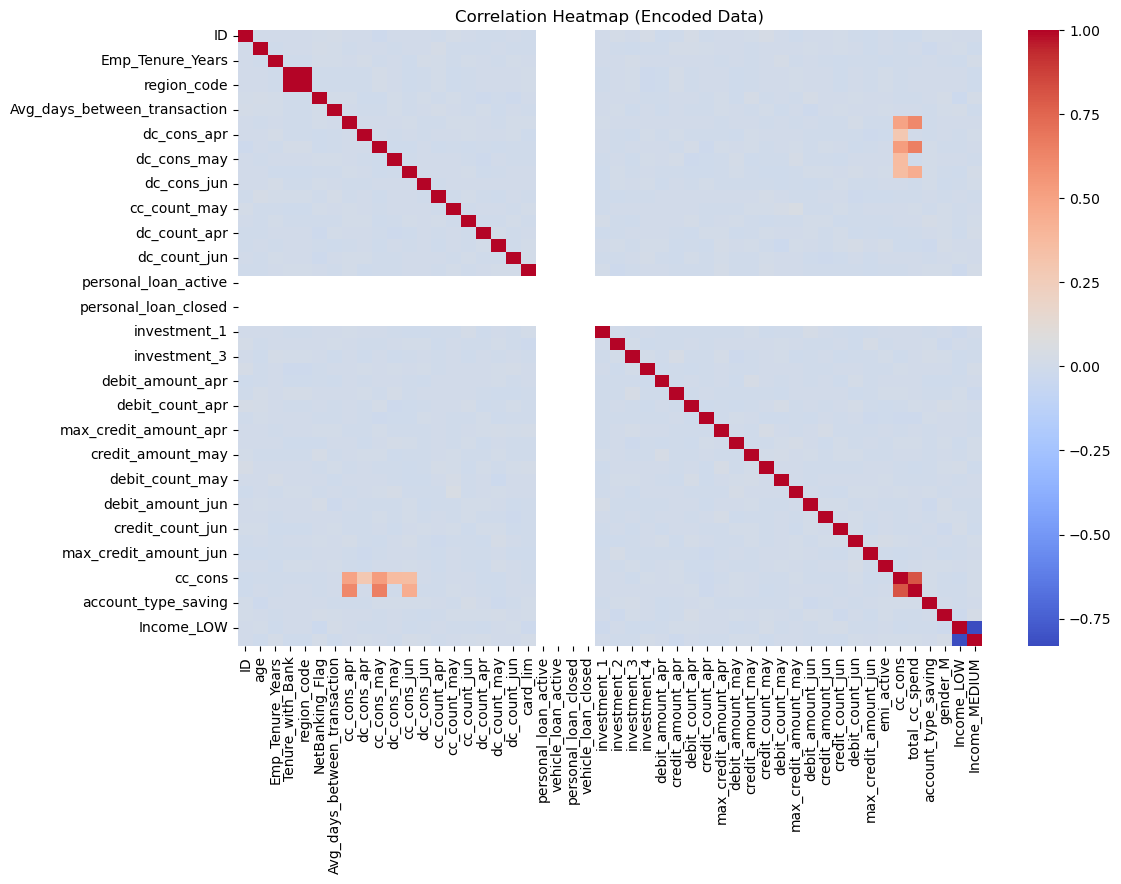

In [35]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_train.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

C:\Users\dssy1\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='cc_cons', ylabel='Count'>

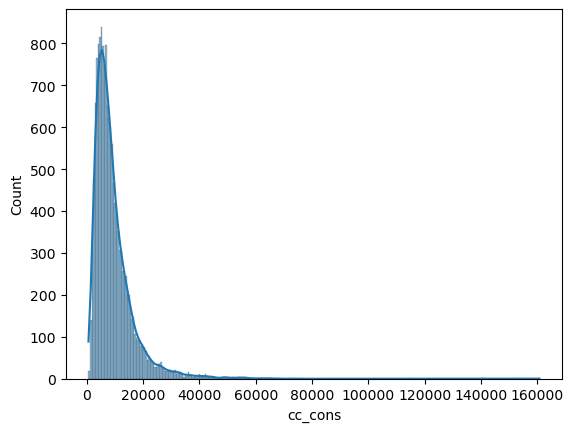

In [36]:
# Distribution of target
sns.histplot(df_train['cc_cons'], kde=True)

In [37]:
# Model Building 

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [39]:
X = df_train.drop(columns=['ID', 'cc_cons'])
y = df_train['cc_cons']

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [42]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

RandomForestRegressor()

In [43]:
# Model Evaluation

In [44]:
from sklearn.metrics import mean_squared_error

In [45]:
def rmspe(y_true, y_pred):
    return np.sqrt(np.mean(np.square((y_true - y_pred) / y_true)))

In [46]:
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

In [50]:
rmspe(y_test, y_pred_lr) # Linear Regression RMSPE

0.27216450624960314

In [51]:
rmspe(y_test, y_pred_rf) # Random Forest RMSPE

0.2810130184080334

In [52]:
# Predict for Missing Target Values 

In [56]:
# Predict for unseen data
df_predict_filled = df_predict.fillna(0)

predictions = rf.predict(df_predict_filled.drop(columns=['ID']))
df_predict_filled['cc_cons_predicted'] = predictions

In [57]:
# Conclusion 

In [58]:
# Insights 